### Question 1: What is Deep Learning? Briefly describe how it evolved and how it differs from traditional machine learning.

Deep Learning is a subfield of Machine Learning that focuses on algorithms inspired by the structure and function of the brain called artificial neural networks. It evolved from early perceptron models to deep neural networks that can automatically extract complex patterns from data. Unlike traditional ML, which relies on handcrafted features, Deep Learning learns hierarchical feature representations directly from raw data using multiple layers of processing.

### Question 2: Explain the basic architecture and functioning of a Perceptron. What are its limitations?

A Perceptron is the simplest type of artificial neural network consisting of input nodes, weights, a summation function, and an activation function. It computes a weighted sum of the inputs and passes it through an activation function to produce output. Limitations include inability to solve non-linear problems (like XOR) and lack of hidden layers.

### Question 3: Describe the purpose of activation function in neural networks. Compare Sigmoid, ReLU, and Tanh functions.

Activation functions introduce non-linearity, allowing neural networks to learn complex patterns. Sigmoid maps values between 0 and 1 but can suffer from vanishing gradients. Tanh maps between -1 and 1 and is zero-centered but also faces gradient issues. ReLU outputs zero for negative inputs and linear for positives, making it computationally efficient and widely used.

### Question 4: What is the difference between Loss function and Cost function in neural networks? Provide examples.

The Loss function measures the error for a single training example, while the Cost function is the average of all individual losses over the entire dataset. For example, Mean Squared Error (MSE) can be a loss function, and the average MSE over all samples forms the cost function.

### Question 5: What is the role of optimizers in neural networks? Compare Gradient Descent, Adam, and RMSprop.

Optimizers adjust model parameters to minimize the loss function. Gradient Descent updates weights in the direction of negative gradient. Adam combines momentum and adaptive learning rate, making it faster. RMSprop adapts learning rates for each parameter and is suitable for recurrent networks.

### Question 6: Write a Python program to implement a single-layer perceptron from scratch using NumPy to solve the logical AND gate.

In [1]:
import numpy as np

# AND gate dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,0,0,1])

# Initialize weights and bias
weights = np.zeros(2)
bias = 0
lr = 0.1

# Training loop
for epoch in range(20):
    for i in range(len(X)):
        linear_output = np.dot(X[i], weights) + bias
        y_pred = 1 if linear_output > 0 else 0
        error = y[i] - y_pred
        weights += lr * error * X[i]
        bias += lr * error

print("Trained weights:", weights)
print("Trained bias:", bias)

# Test
for i in range(len(X)):
    output = np.dot(X[i], weights) + bias
    print(X[i], "->", 1 if output > 0 else 0)

Trained weights: [0.2 0.1]
Trained bias: -0.2
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1


### Question 7: Implement and visualize Sigmoid, ReLU, and Tanh activation functions using Matplotlib.

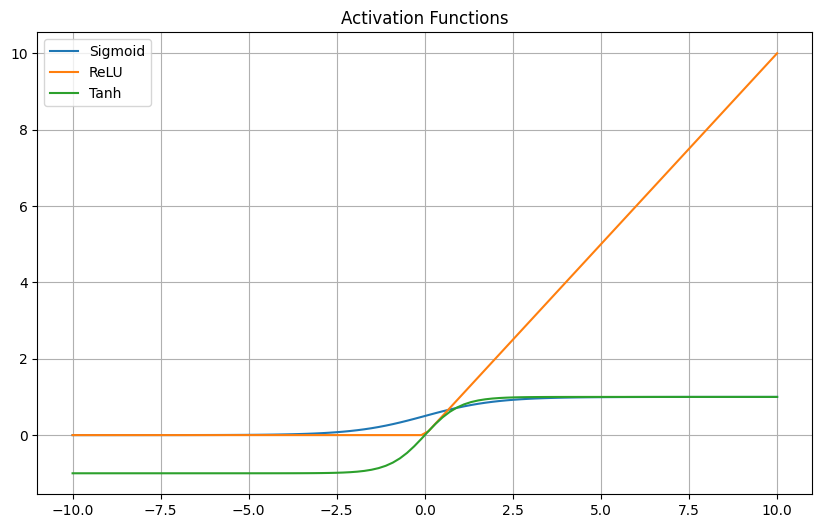

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10,10,100)

sigmoid = 1 / (1 + np.exp(-x))
relu = np.maximum(0, x)
tanh = np.tanh(x)

plt.figure(figsize=(10,6))
plt.plot(x, sigmoid, label='Sigmoid')
plt.plot(x, relu, label='ReLU')
plt.plot(x, tanh, label='Tanh')
plt.title('Activation Functions')
plt.legend()
plt.grid()
plt.show()

### Question 8: Use Keras to build and train a simple multilayer neural network on the MNIST digits dataset. Print the training accuracy.

In [4]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train, y_test = to_categorical(y_train), to_categorical(y_test)

model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=5, batch_size=32, validation_split=0.2)
print("Training Accuracy:", history.history['accuracy'][-1])

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9179 - loss: 0.2899 - val_accuracy: 0.9517 - val_loss: 0.1691
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9624 - loss: 0.1285 - val_accuracy: 0.9640 - val_loss: 0.1242
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9743 - loss: 0.0865 - val_accuracy: 0.9690 - val_loss: 0.1036
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9802 - loss: 0.0641 - val_accuracy: 0.9722 - val_loss: 0.0911
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9844 - loss: 0.0498 - val_accuracy: 0.9747 - val_loss: 0.0897
Training Accuracy: 0.9844375252723694


### Question 9: Visualize the loss and accuracy curves for a neural network model trained on the Fashion MNIST dataset. Interpret the training behavior.

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8206 - loss: 0.5104 - val_accuracy: 0.8577 - val_loss: 0.4011
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8629 - loss: 0.3805 - val_accuracy: 0.8647 - val_loss: 0.3766
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8733 - loss: 0.3447 - val_accuracy: 0.8700 - val_loss: 0.3501
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8835 - loss: 0.3188 - val_accuracy: 0.8777 - val_loss: 0.3379
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8893 - loss: 0.3009 - val_accuracy: 0.8823 - val_loss: 0.3321


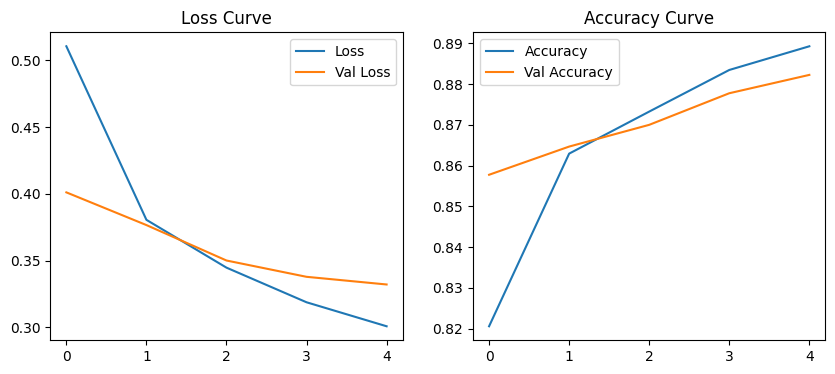

In [6]:
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train, y_test = to_categorical(y_train), to_categorical(y_test)

model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=5, validation_split=0.2)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title('Loss Curve')

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend(); plt.title('Accuracy Curve')
plt.show()

### Question 10: Fraud Detection Deep Learning Workflow Explanation

For a fraud detection task, use a multilayer neural network with input features such as transaction amount, merchant ID, and location. ReLU can be used as the activation function for hidden layers, and Sigmoid for the output layer (binary classification). Use Binary Cross-Entropy as the loss function. Handle class imbalance using class weights or SMOTE. Adam optimizer is suitable for adaptive learning. To prevent overfitting, use dropout and early stopping during training.